In [1]:
from pynq import Overlay, allocate
from PIL import Image
import numpy as np
import matplotlib.pyplot as plt
import struct
import time

In [3]:
print('IP blocks :', list(overlay.ip_dict.keys()))

IP blocks : ['imagefiltering_compu_0', 'axi_dma_0', 'processing_system7_0']


In [4]:
overlay = Overlay("design_1.bit")

dma = overlay.axi_dma_0
ip = overlay.imagefiltering_compu_0

(-0.5, 255.5, 255.5, -0.5)

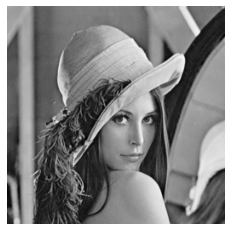

In [5]:
img = Image.open("Lenna.png").convert("L")
img = img.resize((256,256))

image = np.array(img,dtype=np.int32)
height,width = image.shape

plt.imshow(image,cmap="gray")
plt.axis("off")

In [6]:
kernel = np.array([
[-1,-2,-1],
[ 0, 0, 0],
[ 1, 2, 1]
],dtype=np.float32)

def f2u(x):
    return struct.unpack("<I",struct.pack("<f",float(x)))[0]

ip.write(0x18,width)
ip.write(0x20,height)

for i,v in enumerate(kernel.flatten()):
    ip.write(0x40+i*4,f2u(v))

In [7]:
inp = allocate((width*height,),dtype=np.int32)
out = allocate((width*height,),dtype=np.int32)

inp[:] = image.flatten()

inp.flush()
out.flush()

In [8]:
t0=time.time()

dma.recvchannel.transfer(out)
ip.write(0x00,1)
dma.sendchannel.transfer(inp)

dma.sendchannel.wait()
dma.recvchannel.wait()

out.invalidate()

print("Time :",time.time()-t0,"s")

Time : 0.010238170623779297 s


(-0.5, 255.5, 255.5, -0.5)

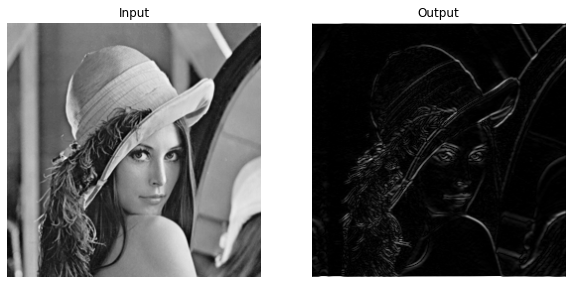

In [9]:
result = np.array(out).reshape(height,width)

result = np.abs(result)

if result.max()!=0:
    result=(255*result/result.max()).astype(np.uint8)

plt.figure(figsize=(10,5))

plt.subplot(121)
plt.imshow(image,cmap="gray")
plt.title("Input")
plt.axis("off")

plt.subplot(122)
plt.imshow(result,cmap="gray")
plt.title("Output")
plt.axis("off")